# Beschreibung #

"""

# DyCA-Eigenwerte für Tennessee Eastman Process (TEP)

Dieses Notebook berechnet für jede Fehlerklasse (`faultNumber` 0-20) und jeden
Simulationslauf (`simulationRun`) die **generalisierten DyCA-Eigenwerte** des
jeweiligen Runs und fasst diese anschließend über die 500 Läufe pro
Fehlerklasse mittels Mittelwert und Standardabweichung zusammen.

**Datensatz**

Kaggle "tep-csv" (afrniomelo):
https://www.kaggle.com/datasets/afrniomelo/tep-csv

- `TEP_FaultFree_Training.csv`  (faultNumber = 0)
- `TEP_Faulty_Training.csv`     (faultNumber = 1..20)

Beide Dateien müssen im aktuellen Arbeitsverzeichnis liegen.

Eigenschaften des Datensatzes (laut Kaggle-Doku):
- Sampling-Intervall: alle 3 Minuten.
- Training: 500 Samples pro Run (= 25 h Simulationsdauer).
- Faulty Training: Fehler wird **1 Stunde nach Simulationsstart** injiziert
  → 60 min / 3 min = **20 Samples Vorlauf**, erstes Post-Fault-Sample ist
  `sample == 21`.

**Konzept**

- Ein `StandardScaler` wird **nur** auf Normalbetrieb (`faultNumber == 0`) aus
  `TEP_FaultFree_Training.csv` gefittet und in `run_dyca_on_group`
  **angewandt** (`X_scaled = scaler.transform(X)`): spaltenweise
  Zentrierung und Skalierung in Normalbetriebs-Einheiten. Die
  m/n-Schätzzelle weiter unten arbeitet damit jetzt auf **derselben**
  Vorverarbeitung wie die Produktivschleife. (Frühere Variante:
  `X - X.mean()`; deren Ergebnisse liegen als `*_global_mean.csv`
  archiviert.)
- Aus einem FaultFree-Run werden vorab die DyCA-Parameter `m` (Anzahl
  linearer Komponenten) und `n` (Dimension des deterministischen Systems)
  geschätzt — analog zum Vorgehen im Rössler-Beispiel der DyCA-Bibliothek.
- Pro Kombination (`faultNumber`, `simulationRun`) wird **DyCA** auf den
  vorverarbeiteten Run-Daten ausgeführt. Die generalisierten Eigenwerte
  (`result["generalized_eigenvalues"]`, shape `(n_features,)` = 52) werden
  als Eigenwertvektor übernommen. Diese Werte liegen in [0, 1] und sind
  bereits absteigend sortiert (`lambda_1` = größter Eigenwert).
- **`m` und `n` haben auf diese Eigenwerte keinen Einfluss.** Das
  `dyca`-Paket löst das verallgemeinerte Eigenwertproblem, *bevor* `m` und
  `n` ausgewertet werden; sie steuern nur `amplitudes` und `singular_values`,
  die dieses Notebook nicht exportiert. Nachgemessen: die Eigenwerte für
  (m,n) = (2,4), (3,6), (4,8) und (6,12) sind bitgleich. Die exportierte
  `dyca_eigenvalues_train.csv` hängt also **nicht** von `M_LINEAR`/`N_TOTAL`
  ab — relevant werden die beiden erst dort, wo die Amplituden verwendet
  werden (`TSFresh_PCA_DyCA.ipynb`).
- Bei Fehlerklassen 1-20 werden die **Pre-Fault-Samples** (`sample < 21`)
  verworfen (Begründung siehe oben). Konsequenz: Fault 0 nutzt 500
  Beobachtungen pro Run, Fault 1-20 jeweils 480.
- Ein Anteil von Runs (rund **4–5 %** unter der früheren
  `X − X.mean()`-Vorverarbeitung, also ~460 von 10 500 — mit dem Scaler
  kann sich der Anteil verschieben, die Diagnose-Zelle weist ihn aus)
  fällt durch DyCA's strenge Sanity-Prüfung (negative Eigenwerte
  durch Floating-Point-Rauschen, siehe `dyca_internal._check_eigenvalues`).
  Diese Runs werden übersprungen und in der Diagnose-Zelle aufgelistet. Der
  Verlust ist **nicht gleichmäßig** über die Klassen verteilt — Fault 6
  trifft es mit Abstand am stärksten.
- Über die verbliebenen Läufe einer Fehlerklasse werden für jeden
  Eigenwertindex Mittelwert und Standardabweichung gebildet.

"""

# Imports #

In [1]:
# !pip install dyca matplotlib numpy pandas scikit-learn tqdm

# DyCA-Bibliothek (Uhl, Stiehl et al. 2024,
# https://doi.org/10.3389/fams.2024.1456635)
from dyca import dyca

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Optional: Fortschrittsbalken fuer lange Schleifen
try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

plt.rcParams["figure.figsize"] = (16, 4)
plt.rcParams["font.size"] = 10

# Parameter #

In [2]:
# ===== Pfade zu den TEP-CSV-Dateien =====
PATH_FAULTFREE_TRAIN = "TEP_FaultFree_Training.csv"
PATH_FAULTY_TRAIN    = "TEP_Faulty_Training.csv"

# ===== Prozessvariablen (wie im PCA-Notebook) =====
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS

META_COLS  = ["faultNumber", "simulationRun", "sample"]

# ===== DyCA-Parameter =====
# m = Anzahl linearer Komponenten
# n = Dimension des deterministischen Systems
# Diese Werte SOLLTEN aus den FaultFree-Daten geschaetzt werden -
# siehe spaetere 'm/n-Schaetzungs'-Zelle. Vorbelegung: aus dem
# Roessler-Beispiel von DyCA, NICHT zwingend optimal fuer TEP.
#
# Randbedingungen aus dyca_internal._input_check:
#   n >= m  und  m >= n - m  (also n <= 2m)
#   z.B. m=2 erlaubt n in {2, 3, 4}; m=3 erlaubt n in {3, 4, 5, 6}.
M_LINEAR = 2
N_TOTAL  = 4

# Hinweis: Ein expliziter Zeitvektor wird bewusst NICHT definiert.
# DyCA defaultet auf time_index = np.arange(n_samples) (siehe dyca.py),
# und die generalisierten Eigenwerte sind ohnehin invariant gegen die
# Zeitskala (lambda haengt nur von dimensionslosen Korrelations-
# Verhaeltnissen ab). Damit ist die Wahl der Zeitskala fuer diese
# Analyse irrelevant.

# Daten laden & Spalten prüfen #

In [3]:
# ============================================================
# Trainingsdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im aktuellen Arbeitsverzeichnis liegen.
#   - TEP_FaultFree_Training.csv : nur faultNumber == 0
#     -> 500 simulationRuns x 500 samples = 250 000 Zeilen
#   - TEP_Faulty_Training.csv    : faultNumber 1..20
#     -> 20 faults x 500 runs x 500 samples = 5 000 000 Zeilen

df_ff_train     = pd.read_csv(PATH_FAULTFREE_TRAIN)
df_faulty_train = pd.read_csv(PATH_FAULTY_TRAIN)

# Nur die benoetigten Spalten behalten (Metadaten + Prozessvariablen).
df_ff_train     = df_ff_train[META_COLS + PROC_COLS]
df_faulty_train = df_faulty_train[META_COLS + PROC_COLS]

print("FaultFree_Training shape:", df_ff_train.shape)
print("Faulty_Training shape   :", df_faulty_train.shape)

# ------------------------------------------------------------
# Spalten-Check
# ------------------------------------------------------------
# Diese drei Spalten brauchen wir spaeter zum Gruppieren der Daten
# nach Fehlerklasse und Simulationslauf.
for col in META_COLS:
    if col not in df_ff_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_FaultFree_Training.csv")
    if col not in df_faulty_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_Faulty_Training.csv")

print("Anzahl Prozessvariablen:", len(PROC_COLS))
print("Beispiel-Variablen:", PROC_COLS[:5])

FaultFree_Training shape: (250000, 55)
Faulty_Training shape   : (5000000, 55)
Anzahl Prozessvariablen: 52
Beispiel-Variablen: ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5']


# StandardScaler auf FaultFree_Training fitten (wird in der Schleife angewandt) #

In [4]:
# ============================================================
# StandardScaler auf FaultFree_Training (Normalbetrieb) fitten
# ============================================================
# Dieser Scaler wird sowohl von der m/n-Schaetzzelle weiter unten als
# auch von run_dyca_on_group benutzt (X_scaled = scaler.transform(X)) -
# m/n-Schaetzung und Produktivschleife arbeiten damit auf derselben
# Vorverarbeitung.

scaler = StandardScaler()
scaler.fit(df_ff_train[PROC_COLS].values)

print("StandardScaler auf FaultFree_Training angepasst.")
print("  Anzahl Features:        ", len(PROC_COLS))
print("  Mittelwerte (Auszug):   ", np.round(scaler.mean_[:5], 4))
print("  Std-Werte (Auszug):     ", np.round(scaler.scale_[:5], 4))

StandardScaler auf FaultFree_Training angepasst.
  Anzahl Features:         52
  Mittelwerte (Auszug):    [2.5050000e-01 3.6637857e+03 4.5088198e+03 9.3471000e+00 2.6902200e+01]
  Std-Werte (Auszug):      [3.09000e-02 3.40063e+01 3.92153e+01 8.57000e-02 2.11500e-01]


# Trainingsdaten zusammenführen (Fault 0-20) #

In [5]:
# ============================================================
# Trainingsdaten zusammenfuehren (Fault 0..20 in EINEM DataFrame)
# ============================================================
# Wir wollen anschliessend EINE Schleife ueber alle Kombinationen
# (faultNumber, simulationRun) laufen lassen. Dafuer fuegen wir
# FaultFree (= Fault 0) und Faulty (= Fault 1..20) zusammen.
#
# df_ff_train hat bereits faultNumber == 0; concat reicht.
# pd.concat mutiert seine Eingaben nicht - kein vorheriges .copy()
# noetig. ignore_index=True vergibt einen neuen, fortlaufenden Index.
df_all = pd.concat(
    [df_ff_train, df_faulty_train],
    ignore_index=True,
)

# Globale Sortierung nach (Fault, Run, Sample). Erleichtert das Lesen
# und stellt sicher, dass die Zeilen jeder Gruppe spaeter zeitlich
# geordnet vorliegen (wichtig fuer DyCA's Ableitungsberechnung).
df_all = df_all.sort_values(
    ["faultNumber", "simulationRun", "sample"]
).reset_index(drop=True)

print("Kombinierte Trainingsdaten shape:", df_all.shape)
print("FaultNumbers im kombinierten Datensatz:",
      sorted(df_all["faultNumber"].unique()))

Kombinierte Trainingsdaten shape: (5250000, 55)
FaultNumbers im kombinierten Datensatz: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


# m/n-Schätzung aus FaultFree-Daten #

Referenz-Run shape: (500, 52)


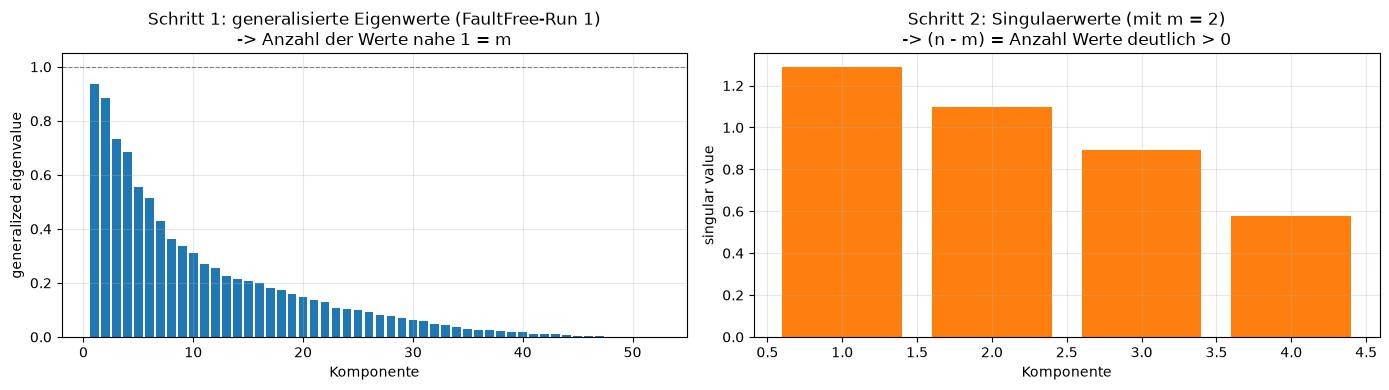


Aktuelle Einstellung: M_LINEAR = 2, N_TOTAL = 4
Wenn die Plots eine andere Wahl nahelegen, oben in der Imports-
Zelle aendern und beide Zellen neu ausfuehren.


In [6]:
# ============================================================
# Schaetzung von m und n auf einem FaultFree-Run
# ============================================================
# Vorgehen entspricht dem Roessler-Beispiel (roessler70_example.ipynb):
#
#   Schritt 1:  dyca(...) OHNE m, n auf einem Normalbetriebs-Run.
#               Anzahl der generalisierten Eigenwerte nahe 1 = m.
#   Schritt 2:  dyca(..., m=m) mit dem geschaetzten m.
#               Anzahl Singulaerwerte deutlich groesser 0 (Plateau) + m = n.
#
# Lies m und n aus den Balkendiagrammen ab und trage sie ggf. oben
# in M_LINEAR / N_TOTAL ein.
#
# EINSCHRAENKUNG, die beim Ablesen zu beachten ist (seit der Umstellung
# arbeiten Schaetzzelle UND run_dyca_on_group auf scaler.transform -
# die fruehere Diskrepanz zwischen beiden ist behoben):
#
#    Auf den TEP-Daten liegt KEIN Eigenwert nahe 1 (groesster Wert ~0,94,
#    danach 0,88 / 0,73 / 0,69 / 0,55 - ein glatter Abfall ohne Knick).
#    Das Kriterium "Anzahl der Werte nahe 1" ist hier deshalb nicht
#    trennscharf: M_LINEAR = 2 entspricht einer Schwelle von etwa 0,8.
#
# Fuer die EXPORTIERTEN Eigenwerte ist das folgenlos - sie haengen nicht
# von m/n ab (siehe Beschreibung oben). Relevant wird die Wahl erst dort,
# wo die Amplituden benutzt werden (TSFresh_PCA_DyCA.ipynb).

# Einen FaultFree-Run (simulationRun = 1) als Referenz ziehen.
ref_run = (
    df_ff_train[df_ff_train["simulationRun"] == 1]
    .sort_values("sample")
)
X_ref         = ref_run[PROC_COLS].values
X_ref_scaled  = scaler.transform(X_ref)

print("Referenz-Run shape:", X_ref_scaled.shape)


# ------------------------------------------------------------
# Schritt 1: m bestimmen (generalisierte Eigenwerte)
# ------------------------------------------------------------
# Ohne time_index -> DyCA defaultet auf np.arange(n_samples).
# Eigenwerte sind zeitskalen-invariant, also egal.
result_step1 = dyca(X_ref_scaled)
eigvals_step1 = np.asarray(result_step1["generalized_eigenvalues"], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, len(eigvals_step1) + 1), eigvals_step1)
axes[0].set_title("Schritt 1: generalisierte Eigenwerte (FaultFree-Run 1)\n"
                  "-> Anzahl der Werte nahe 1 = m")
axes[0].set_xlabel("Komponente")
axes[0].set_ylabel("generalized eigenvalue")
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Schritt 2: n bestimmen (Singulaerwerte mit gegebenem m)
# ------------------------------------------------------------
result_step2    = dyca(X_ref_scaled, m=M_LINEAR)
singular_values = np.asarray(result_step2["singular_values"], dtype=float)

# Knickpunkt-Heuristik: n - m = Anzahl Singulaerwerte vor dem Abfall.
axes[1].bar(range(1, len(singular_values) + 1), singular_values, color="tab:orange")
axes[1].set_title(f"Schritt 2: Singulaerwerte (mit m = {M_LINEAR})\n"
                  f"-> (n - m) = Anzahl Werte deutlich > 0")
axes[1].set_xlabel("Komponente")
axes[1].set_ylabel("singular value")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAktuelle Einstellung: M_LINEAR = {M_LINEAR}, N_TOTAL = {N_TOTAL}")
print("Wenn die Plots eine andere Wahl nahelegen, oben in der Imports-")
print("Zelle aendern und beide Zellen neu ausfuehren.")

# Funktion: DyCA-Eigenwerte pro Run #

In [7]:
def run_dyca_on_group(
    group: pd.DataFrame,
    scaler: StandardScaler,
    proc_cols: list,
    m: int,
    n: int,
):
    """
    Fuehrt DyCA auf einem einzelnen (faultNumber, simulationRun)-Subsample
    aus und gibt das Array der generalisierten Eigenwerte zurueck.

    Parameter
    ---------
    group : pd.DataFrame
        Genau EIN Run, Zeilen = Samples in zeitlicher Reihenfolge.
    scaler : StandardScaler
        Auf FaultFree gefittet und hier ANGEWANDT
        (X_scaled = scaler.transform(X)).
    proc_cols : list[str]
        Prozessvariablen-Spalten (xmeas_*, xmv_*).
    m : int
        Anzahl linearer Komponenten (aus FaultFree geschaetzt).
    n : int
        Dimension des deterministischen Systems (aus FaultFree geschaetzt).
        Hinweis: m und n haben auf den Rueckgabewert dieser Funktion GAR
        KEINEN Einfluss - weder auf die Anzahl der Eigenwerte (immer 52)
        noch auf deren Werte. Das Paket loest das verallgemeinerte
        Eigenwertproblem, BEVOR m/n ausgewertet werden; sie steuern nur
        amplitudes und singular_values, die hier nicht zurueckgegeben
        werden. Nachgemessen: (2,4), (3,6), (4,8), (6,12) liefern
        bitgleiche Eigenwerte.

    Rueckgabewert
    -------------
    eigvals : np.ndarray
        Generalisierte Eigenwerte, shape (n_features,) = 52, bereits
        absteigend sortiert. DyCA sortiert intern via argsort+flip
        (siehe dyca_internal.py::_calculate_eigenvalues_and_vectors),
        daher ist hier kein zusaetzliches Sortieren noetig.

    Hinweis zur Zeitskala
    ---------------------
    Es wird BEWUSST kein time_index uebergeben - DyCA defaultet auf
    np.arange(n_samples), und die Eigenwerte sind zeitskalen-invariant
    (siehe Korrelationsmatrizen in dyca_internal._calculate_correlations:
    eine Zeitskalierung um Faktor k laesst lambda unveraendert, da sich
    C1 mit 1/k und C2 mit 1/k^2 transformiert und sich beim
    generalisierten Eigenwertproblem wegkuerzt).
    """

    # 0) Defensive Sortierung nach 'sample'.
    # DyCA bildet intern Zeitableitungen ueber aufeinanderfolgende
    # Zeilen - die Reihenfolge muss daher zeitlich korrekt sein. Die
    # aufrufende Schleife sortiert global vor, aber falls der Helper
    # direkt mit einer unsortierten Gruppe aufgerufen wird, faengt
    # diese Zeile das Problem ab.
    if "sample" in group.columns:
        group = group.sort_values("sample")

    # 1) Messmatrix dieses Runs extrahieren.
    # Shape: (n_samples, n_features) = z.B. (480, 52)
    X = group[proc_cols].values

    # 2) Vorverarbeitung: spaltenweise Standardisierung in Normalbetriebs-
    # Einheiten (Scaler auf FaultFree gefittet). Der grosse statische
    # Gleichanteil der Rohvariablen ist damit entfernt; was in der
    # unzentrierten Korrelationsmatrix C0 = X^T X / T verbleibt, ist die
    # fault-bedingte Mittelwertverschiebung. (Fruehere Variante:
    # X - X.mean() - dort dominierte der Gleichanteil C0.)
    X_scaled = scaler.transform(X)  # frueher (global_mean): X_scaled = X - X.mean()

    # 3) DyCA aufrufen. m, n steuern die Komponentenauswahl fuer
    # amplitudes/SVD, NICHT die Laenge des Eigenwertvektors. Kein
    # time_index -> DyCA-Default (np.arange(n_samples)), Ergebnis
    # identisch wie mit physikalischer Zeit (siehe Docstring).
    result = dyca(X_scaled, m=m, n=n)

    # 4) Generalisierte Eigenwerte uebernehmen.
    # Bereits absteigend sortiert von DyCA, also direkt lambda_1 .. lambda_K.
    eigvals = np.asarray(result["generalized_eigenvalues"], dtype=float)
    return eigvals


def compute_dyca_eigenvalues_per_run(
    df: pd.DataFrame,
    proc_cols: list,
    scaler: StandardScaler,
    m: int,
    n: int,
    drop_pre_fault: bool = True,
    pre_fault_cutoff: int = 21,
):
    """
    Erzeugt einen DataFrame mit DyCA-Eigenwerten pro
    (faultNumber, simulationRun) - analog zu compute_eigenvalues_per_run
    im PCA-Notebook.

    Bei Fault != 0 werden die Pre-Fault-Samples (sample < pre_fault_cutoff)
    verworfen. Laut Kaggle-Doku wird der Fehler im Faulty Training 1 Stunde
    nach Simulationsstart injiziert (= 20 Samples bei 3-min-Sampling),
    erstes Post-Fault-Sample = sample 21.

    Parameter
    ---------
    df : pd.DataFrame
        Bereits kombinierte und sortierte Trainingsdaten mit Spalten
        'faultNumber', 'simulationRun', 'sample' und Prozessvariablen.
    proc_cols : list[str]
        Namen der Prozessvariablen (xmeas_*, xmv_*).
    scaler : StandardScaler
        Auf FaultFree_Training angepasster StandardScaler.
    m, n : int
        DyCA-Parameter (aus FaultFree geschaetzt).
    drop_pre_fault : bool
        Wenn True, werden bei Fault != 0 alle Samples mit
        sample < pre_fault_cutoff verworfen.
    pre_fault_cutoff : int
        Erster Sample-Index, der als 'post-fault' gilt.

    Rueckgabewert
    -------------
    df_eigs : pd.DataFrame
        Eine Zeile pro (faultNumber, simulationRun). Spalten:
            'faultNumber', 'simulationRun',
            'dyca_1', 'dyca_2', ..., 'dyca_K'
        K = Anzahl Features = 52. DyCA liefert immer das vollstaendige
        Spektrum zurueck, unabhaengig von m und n.
    """

    # ----------------------------------------------------------
    # Schritt 1: Gruppierung nach (Fault, Run)
    # ----------------------------------------------------------
    # groupby erzeugt einen Iterator ueber Teil-DataFrames - einen
    # pro (faultNumber, simulationRun)-Kombination. Bei 21 Faults *
    # 500 Runs ergibt das 10 500 Gruppen.
    grouped = df.groupby(["faultNumber", "simulationRun"], sort=True)

    # tqdm zeigt einen Fortschrittsbalken; DyCA pro Run ist deutlich
    # langsamer als PCA -> sonst sitzt man minutenlang im Dunkeln.
    iterator = grouped
    if tqdm_available:
        iterator = tqdm(grouped, desc="Berechne DyCA-Eigenwerte pro Run")

    records      = []
    error_count  = 0
    skip_count   = 0
    first_errors = []   # die ersten paar Fehlermeldungen sammeln

    # ----------------------------------------------------------
    # Schritt 2: Pro Gruppe DyCA ausfuehren
    # ----------------------------------------------------------
    for (fault, run), group in iterator:

        # 2a) Pre-Fault-Bereich verwerfen (nur Fault != 0).
        if drop_pre_fault and fault != 0:
            group = group[group["sample"] >= pre_fault_cutoff]

        # 2b) Robuste Untergrenze. Geprueft wird hier len(group) >=
        # max(m, n) + 5, also bei m=2/n=4 lediglich >= 9 Samples. Die
        # eigentliche Bedingung von dyca_internal._input_check ist
        # schaerfer (n_samples > n_features, also > 52) und wuerde erst
        # im dyca-Aufruf zuschlagen; bei den vorliegenden Runlaengen
        # (Fault 0: 500, Fault 1-20 nach Filterung: 480) greift ohnehin
        # keine der beiden Schranken.
        if len(group) < max(m, n) + 5:
            skip_count += 1
            continue

        # 2c) DyCA-Aufruf kann mit "Negative eigenvalues detected" o.ae.
        # fehlschlagen, wenn das Signal nahe rangdefizient ist
        # (passiert sporadisch bei TEP, siehe dyca_internal._check_eigenvalues:
        # die Pruefung verwendet KEINE Toleranz, ein eigenvalue < 0
        # durch Floating-Point-Noise reicht aus). Fehler werden gesammelt
        # und am Ende aggregiert ausgegeben.
        try:
            eigvals = run_dyca_on_group(
                group=group,
                scaler=scaler,
                proc_cols=proc_cols,
                m=m,
                n=n,
            )

            row = {
                "faultNumber":   fault,
                "simulationRun": run,
            }
            for k, val in enumerate(eigvals, start=1):
                row[f"dyca_{k}"] = float(val)
            records.append(row)

        except Exception as e:
            error_count += 1
            if len(first_errors) < 5:
                first_errors.append(f"  fault={fault}, run={run}: {e}")

    # ----------------------------------------------------------
    # Schritt 3: Ergebnis-DataFrame zusammenbauen + Zusammenfassung
    # ----------------------------------------------------------
    df_eigs = pd.DataFrame.from_records(records)

    # Spalten-Reihenfolge: meta zuerst, dann dyca_1, dyca_2, ...
    eig_cols = [c for c in df_eigs.columns if c.startswith("dyca_")]
    eig_cols = sorted(eig_cols, key=lambda c: int(c.split("_")[1]))
    df_eigs  = df_eigs[["faultNumber", "simulationRun"] + eig_cols]

    print("Erfolgreiche Runs:", len(df_eigs))
    print("Uebersprungen   :", skip_count)
    print("Fehler          :", error_count)
    if first_errors:
        print("Erste Fehler:")
        for line in first_errors:
            print(line)

    return df_eigs

# Anwendung: DyCA-Eigenwerte für alle (Fault, Run)-Kombinationen #

In [8]:
# DyCA-Eigenwerte fuer alle Faults und Runs in den Trainingsdaten berechnen.
#
# Pre-Fault-Cutoff = 21:
#   Laut Kaggle-Doku (afrniomelo/tep-csv) wird der Fehler im Faulty
#   Training 1 Stunde nach Simulationsstart injiziert. Bei einem
#   Sampling-Intervall von 3 min entspricht das 20 Samples Vorlauf,
#   d.h. das erste Post-Fault-Sample hat sample == 21.

dyca_eigenvalues_per_run = compute_dyca_eigenvalues_per_run(
    df=df_all,
    proc_cols=PROC_COLS,
    scaler=scaler,
    m=M_LINEAR,
    n=N_TOTAL,
    drop_pre_fault=True,
    pre_fault_cutoff=21,
)

print("DyCA-Eigenwerte pro Run shape:", dyca_eigenvalues_per_run.shape)
dyca_eigenvalues_per_run.head() 

Berechne DyCA-Eigenwerte pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10443
Uebersprungen   : 0
Fehler          : 57
Erste Fehler:
  fault=0, run=170: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=15: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=93: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=227: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
  fault=1, run=338: Negative eigenvalues detected. 
Numerical instability might be the cause, check the rank of the input signal.
DyCA-Eigenwerte pro Run shape: (10443, 54)


,faultNumber,simulationRun,dyca_1,dyca_2,dyca_3,dyca_4,dyca_5,dyca_6,dyca_7,dyca_8,...,dyca_43,dyca_44,dyca_45,dyca_46,dyca_47,dyca_48,dyca_49,dyca_50,dyca_51,dyca_52
0,0,1,0.937925,0.884058,0.731876,0.683042,0.553713,0.515547,0.429585,0.363507,...,0.009682,0.006073,0.004243,0.002865,0.002230,0.001380,0.000989,0.000064,0.000031,4.945879e-08
1,0,2,0.951325,0.929498,0.804556,0.754866,0.534190,0.498709,0.437902,0.402709,...,0.006848,0.005209,0.004251,0.003157,0.002878,0.002342,0.001088,0.000922,0.000401,2.223355e-04
2,0,3,0.930672,0.906695,0.736079,0.715722,0.534306,0.493845,0.413278,0.395503,...,0.007774,0.007267,0.005547,0.004385,0.002838,0.001408,0.001227,0.001175,0.000011,6.086561e-09
3,0,4,0.934602,0.907673,0.771981,0.676296,0.574108,0.502733,0.429072,0.401868,...,0.011595,0.008988,0.005812,0.004855,0.003128,0.001962,0.001384,0.000647,0.000087,4.001539e-05
4,0,5,0.938671,0.878161,0.770026,0.625239,0.530168,0.481434,0.467164,0.413289,...,0.008330,0.007109,0.006130,0.004349,0.004160,0.002866,0.002158,0.000654,0.000064,3.624826e-05


# Diagnose: erfolgreiche Runs pro Fehlerklasse #

In [9]:
# ============================================================
# Diagnose: Verteilung der erfolgreichen Runs pro Fehlerklasse
# ============================================================
# Bei TEP-FaultFree-Runs kann DyCA gelegentlich an "Negative eigenvalues
# detected" scheitern (nahe rangdefiziente Signale im Normalbetrieb).
# Diese Zelle zeigt, wie viele Runs pro Fehlerklasse erfolgreich
# verarbeitet wurden und wie viele verloren gingen (von erwarteten 500).

runs_per_fault = dyca_eigenvalues_per_run.groupby("faultNumber").size()
loss_per_fault = 500 - runs_per_fault

print("Erfolgreiche Runs pro Fault:")
print(runs_per_fault.to_string())

losses = loss_per_fault[loss_per_fault > 0]
if len(losses) == 0:
    print("\nKein Verlust - alle 500 Runs pro Fault erfolgreich.")
else:
    print("\nVerlust pro Fault (von 500):")
    print(losses.to_string())
    print(f"\nGesamt-Verlust: {losses.sum()} / {21 * 500} "
          f"({100 * losses.sum() / (21 * 500):.2f} %)")

Erfolgreiche Runs pro Fault:
faultNumber
0     499
1     496
2     498
3     498
4     498
5     500
6     495
7     498
8     498
9     497
10    499
11    499
12    497
13    495
14    497
15    496
16    497
17    497
18    495
19    497
20    497

Verlust pro Fault (von 500):
faultNumber
0     1
1     4
2     2
3     2
4     2
6     5
7     2
8     2
9     3
10    1
11    1
12    3
13    5
14    3
15    4
16    3
17    3
18    5
19    3
20    3

Gesamt-Verlust: 57 / 10500 (0.54 %)


# Aggregation: Mittelwert & Standardabweichung pro Fehlerklasse #

In [10]:
# ============================================================
# Pro Fehlerklasse: Mittelwert und Standardabweichung jedes Eigenwerts
# ============================================================
# Ausgangspunkt: dyca_eigenvalues_per_run hat eine Zeile pro (Fault, Run)
# mit den Eigenwerten als Spalten dyca_1 .. dyca_K.
# Ziel:          eine Zeile pro Fault mit Mittelwert UND Std jedes
#                Eigenwerts ueber die 500 Runs der Klasse.

# Spalten-Liste der Eigenwerte (alles, was mit "dyca_" anfaengt).
eig_cols = [c for c in dyca_eigenvalues_per_run.columns if c.startswith("dyca_")]

# Gruppieren nach faultNumber und in EINEM Schritt mean+std je
# Eigenwert-Spalte aggregieren. pandas-Std benutzt ddof=1
# (Stichproben-Std), passt fuer N=500.
agg = (
    dyca_eigenvalues_per_run
    .groupby("faultNumber")[eig_cols]
    .agg(["mean", "std"])
)

# MultiIndex-Spalten ('dyca_1', 'mean') -> 'dyca_1_mean' flachklopfen.
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]

# faultNumber war Group-Key (Index) - jetzt wieder als normale Spalte.
agg = agg.reset_index()

print("Aggregierte DyCA-Eigenwert-Statistiken pro Fault:")
print("  shape:", agg.shape)
agg.head()

Aggregierte DyCA-Eigenwert-Statistiken pro Fault:
  shape: (21, 105)


,faultNumber,dyca_1_mean,dyca_1_std,dyca_2_mean,dyca_2_std,dyca_3_mean,dyca_3_std,dyca_4_mean,dyca_4_std,dyca_5_mean,...,dyca_48_mean,dyca_48_std,dyca_49_mean,dyca_49_std,dyca_50_mean,dyca_50_std,dyca_51_mean,dyca_51_std,dyca_52_mean,dyca_52_std
0,0,0.931788,0.008202,0.889915,0.018190,0.760545,0.028084,0.667612,0.036494,0.534702,...,0.001776,0.000613,0.000882,0.000415,0.000522,0.000331,0.000117,0.000119,0.000030,0.000052
1,1,0.984565,0.002572,0.956127,0.004943,0.926065,0.008160,0.780618,0.018415,0.693309,...,0.001542,0.000632,0.000836,0.000410,0.000381,0.000244,0.000114,0.000107,0.000016,0.000027
2,2,0.943312,0.005631,0.910242,0.011518,0.808294,0.022283,0.700710,0.024380,0.551253,...,0.001490,0.000544,0.000849,0.000380,0.000391,0.000239,0.000116,0.000107,0.000014,0.000025
3,3,0.932797,0.008309,0.892401,0.018285,0.764173,0.027969,0.672603,0.035855,0.537449,...,0.001818,0.000682,0.000962,0.000446,0.000536,0.000323,0.000130,0.000127,0.000028,0.000051
4,4,0.932709,0.008255,0.893406,0.017957,0.770326,0.027674,0.676834,0.033499,0.578238,...,0.001507,0.000566,0.000834,0.000381,0.000360,0.000225,0.000110,0.000102,0.000012,0.000022


# Visualisierung: mittlere Eigenwertspektren je Fehlerklasse #

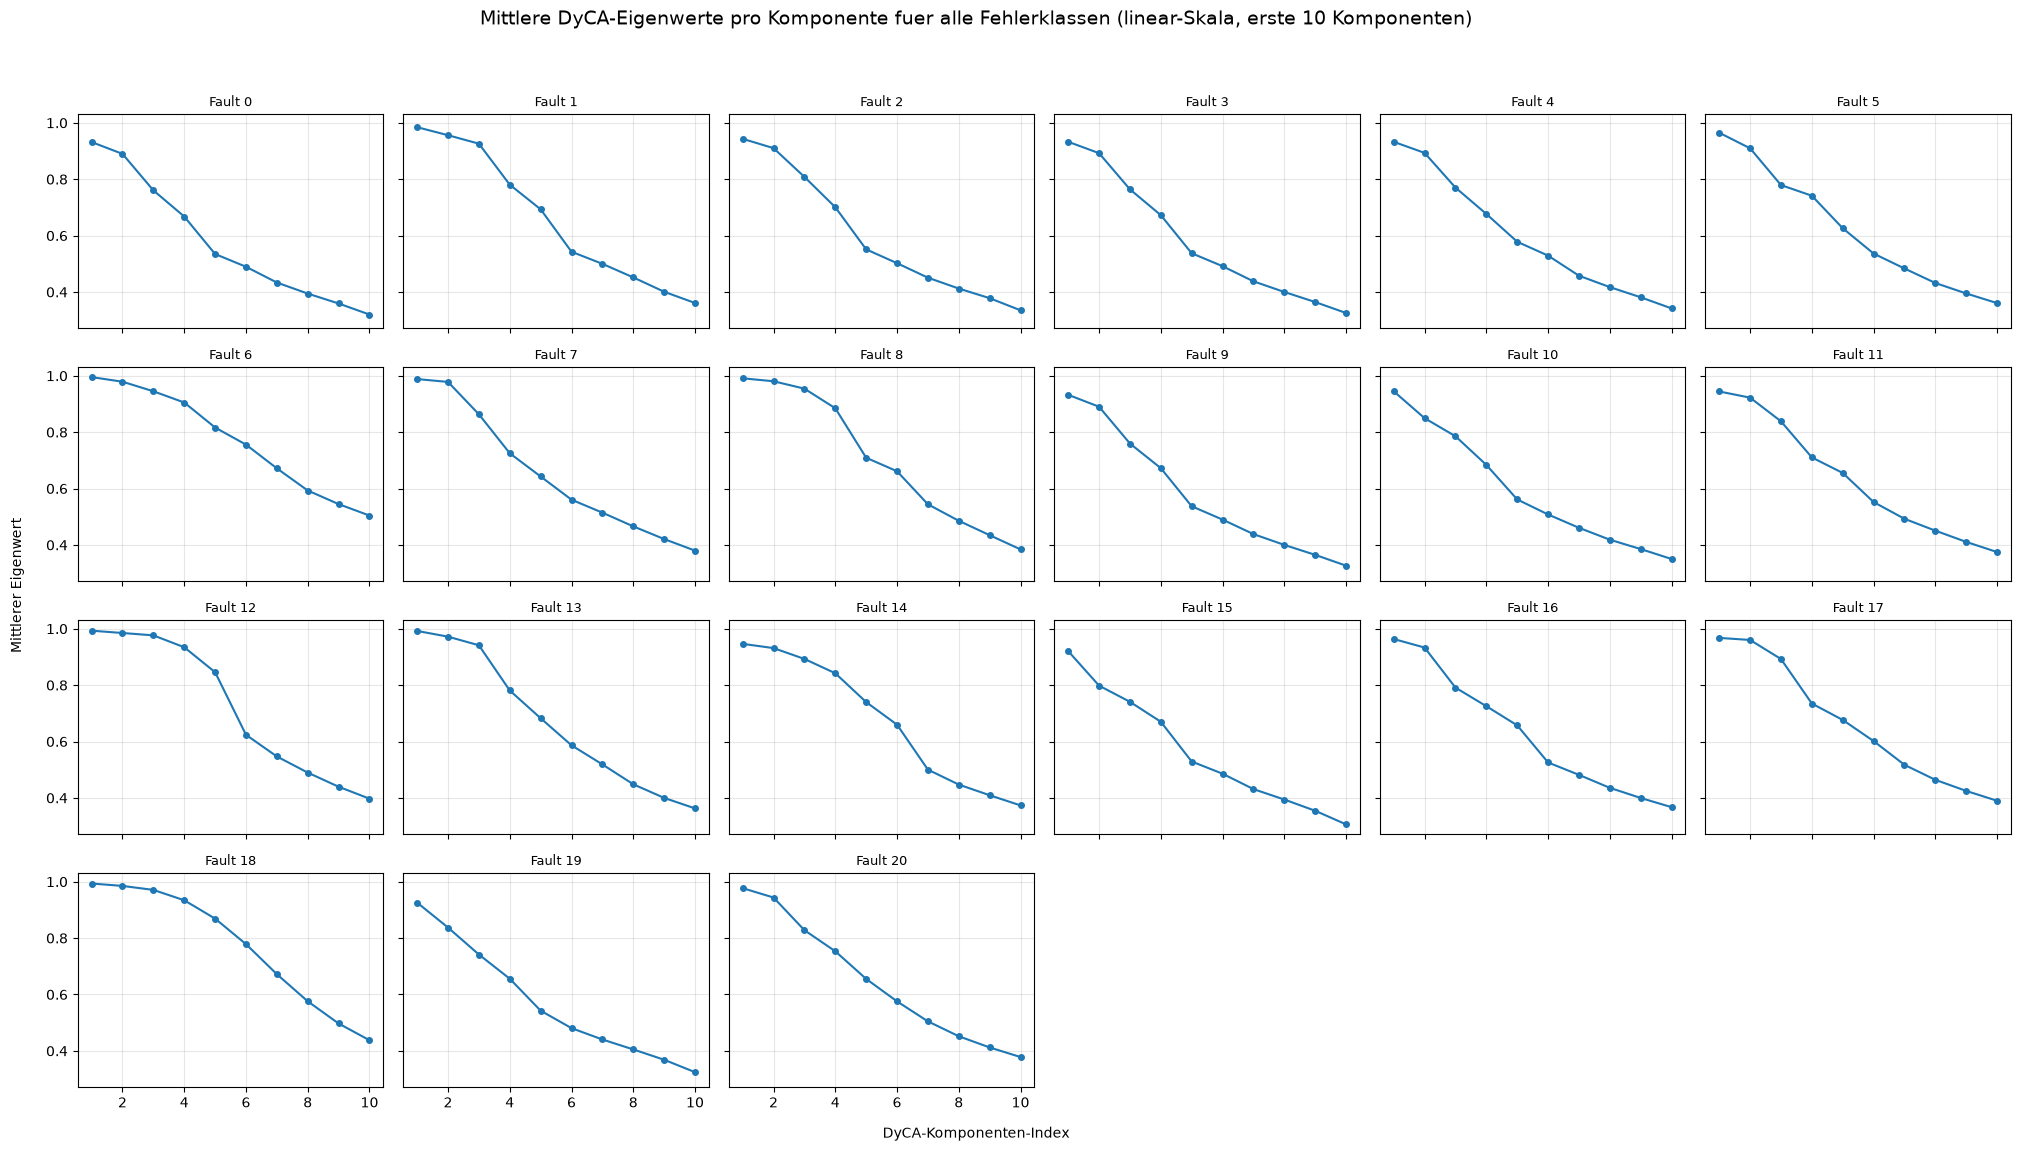

In [11]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der mittlere
# Eigenwertverlauf ueber die ersten k Komponenten.
# ============================================================

# Begrenzung der dargestellten Komponenten - analog zu k_max im
# PCA-Notebook. DyCA gibt das volle Spektrum (52 Werte) zurueck, die
# hinteren Eigenwerte sind aber nahe Null (Noise-Subspace).
K_MAX_DYCA = 10


# ============================================================
# Hilfsfunktion: Transformation der Eigenwerte vor dem Plotten
# ============================================================
def transform_eigenvalues(vals, mode="log"):
    """
    Transformiert einen Vektor von Eigenwerten fuer die Darstellung.

    mode = "linear"   -> keine Transformation. Bei DyCA gut lesbar,
                         weil generalisierte Eigenwerte in [0, 1] liegen.
    mode = "log"      -> log10(Eigenwert). Macht Groessenordnungs-
                         Unterschiede zwischen Komponenten sichtbar
                         (sinnvoll bei vollem Spektrum mit dyca_52 ~ 1e-8).
    mode = "relative" -> Eigenwert / lambda_1. Zeigt nur das "Profil"
                         des Spektrums, unabhaengig vom Absolutniveau
                         einer Fault.
    """
    vals = np.asarray(vals, dtype=float)

    if mode == "linear":
        return vals

    if mode == "log":
        # log10(0) ist -inf -> kleinen Offset einsetzen, um Plot-NaNs zu vermeiden.
        eps = 1e-12
        return np.log10(np.maximum(vals, eps))

    if mode == "relative":
        if vals[0] <= 0:
            # Defensiver Fallback: bei lambda_1 <= 0 (numerisch entartet)
            # waere die Normierung undefiniert.
            return vals
        return vals / vals[0]

    raise ValueError(f"Unbekannter mode: {mode}")


# Darstellungsmodus fuer Mittelwert- UND Std-Plot:
#   "linear"   -> rohe Eigenwerte (bei DyCA in [0, 1] gut lesbar)
#   "log"      -> log10, empfohlen wenn das volle Spektrum geplottet wird
#                 (Eigenwerte spannen ~10 Groessenordnungen)
#   "relative" -> normiert auf lambda_1, zeigt nur Form des Spektrums
plot_mode = "linear"


def plot_dyca_means_per_fault(agg_df, eig_prefix="dyca_", k_max=K_MAX_DYCA):
    # Alle Mittelwert-Spalten aufsteigend nach Komponenten-Index sortieren.
    eig_cols_mean = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_mean")
    ]
    eig_cols_mean = sorted(eig_cols_mean, key=lambda c: int(c.split("_")[1]))

    # Auf die ersten k_max Komponenten begrenzen.
    eig_cols_mean = eig_cols_mean[:k_max]
    K = len(eig_cols_mean)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    # Subplot-Raster (max 6 Spalten - wie im PCA-Notebook).
    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        y      = np.array([row[c] for c in eig_cols_mean], dtype=float)
        y_vals = transform_eigenvalues(y, mode=plot_mode)

        ax.plot(x, y_vals, "o-", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    # Unbenutzte Achsen ausblenden.
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # y-Achsen-Beschriftung passt sich an den gewaehlten Modus an.
    if plot_mode == "log":
        y_label = "log10(Mittlerer Eigenwert)"
    elif plot_mode == "relative":
        y_label = "Mittlerer Eigenwert / lambda_1"
    else:
        y_label = "Mittlerer Eigenwert"

    fig.suptitle(
        f"Mittlere DyCA-Eigenwerte pro Komponente fuer alle Fehlerklassen "
        f"({plot_mode}-Skala, erste {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "DyCA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_dyca_means_per_fault(agg)

# Visualisierung: Standardabweichungs-Spektren je Fehlerklasse #

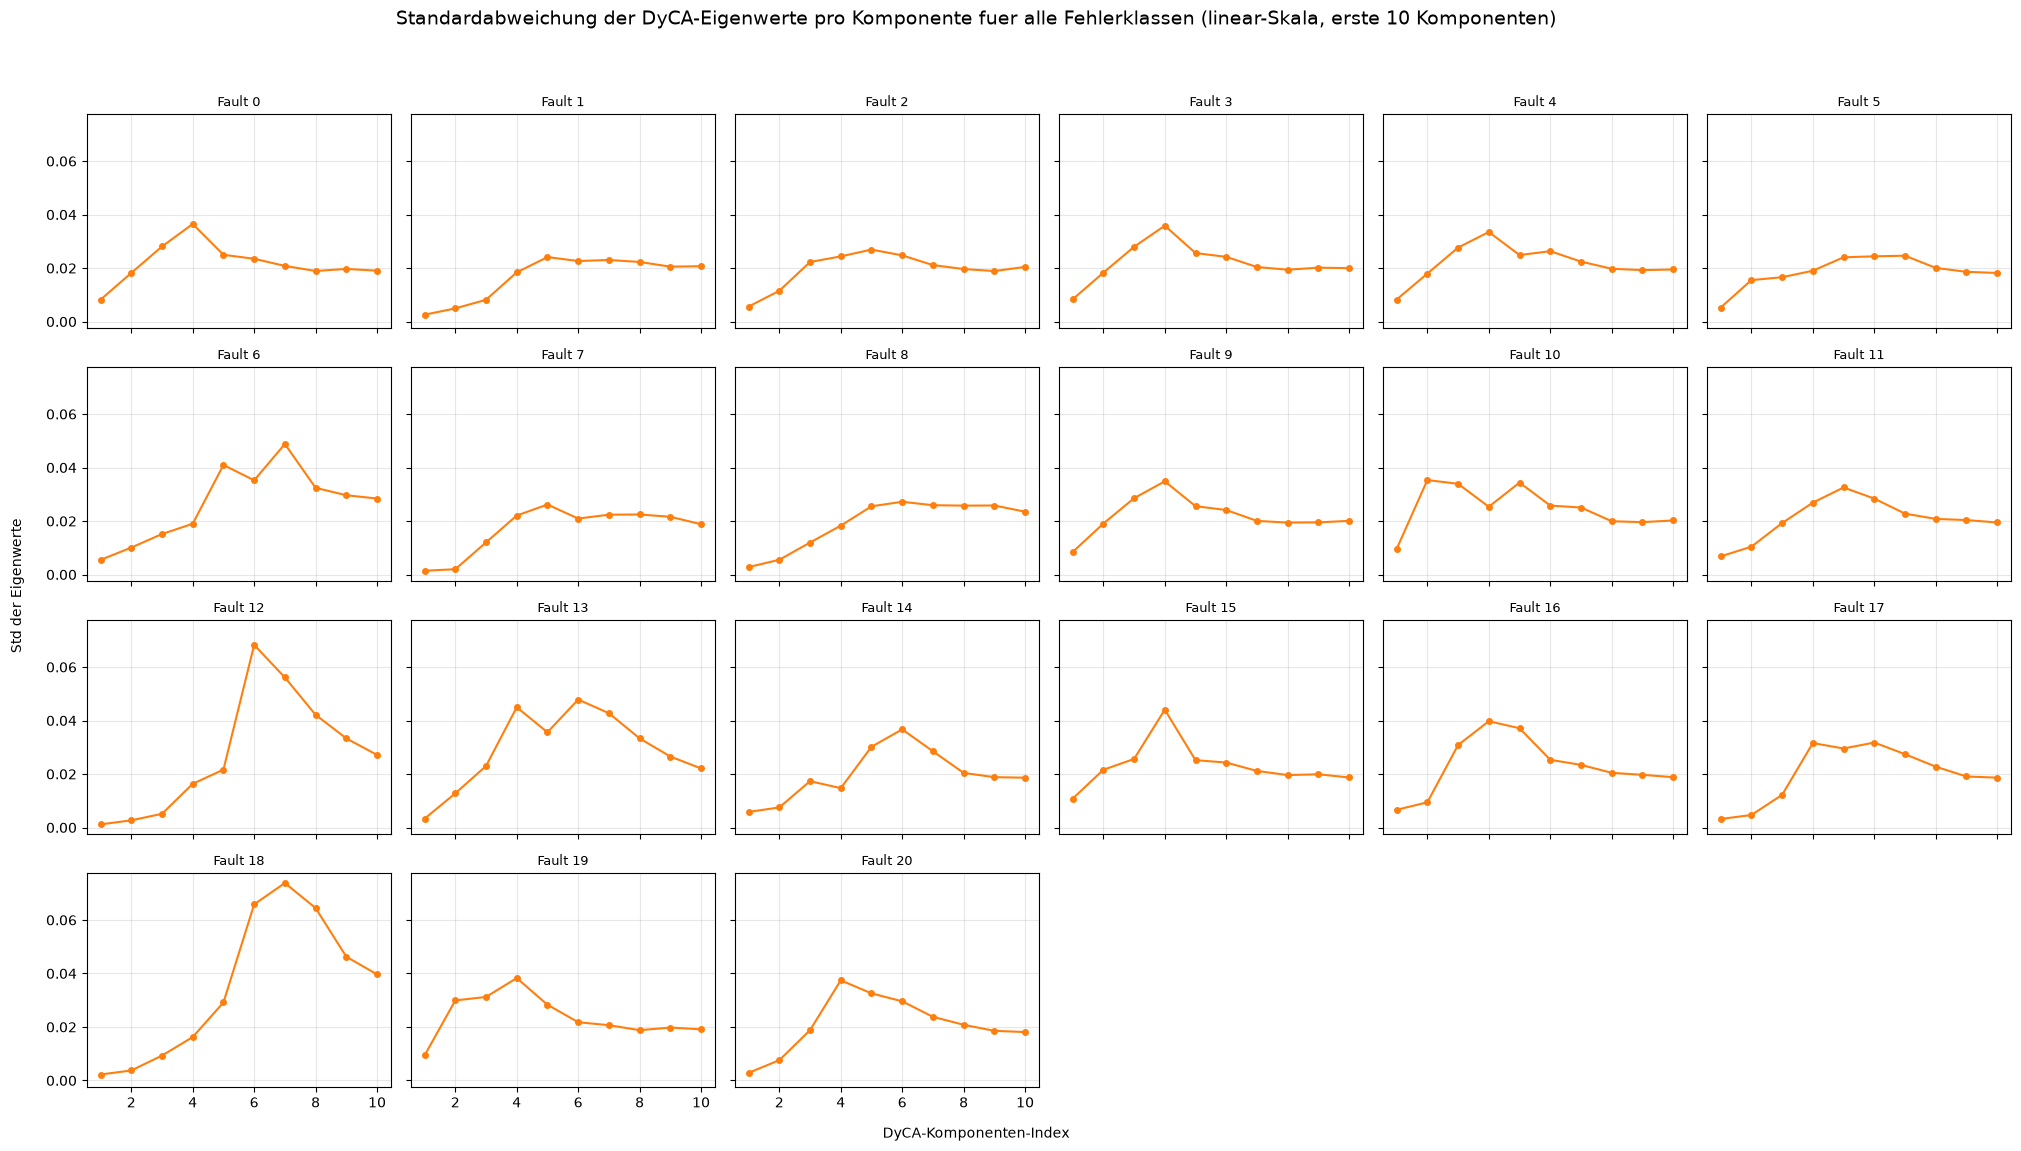

In [12]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der STANDARDABWEICHUNG der Eigenwerte ueber die ersten k Komponenten.
# Struktur identisch zum Mittelwerts-Plot, orange Linienfarbe.
# K_MAX_DYCA, transform_eigenvalues und plot_mode kommen aus der
# Mittelwerts-Zelle.
# ============================================================

def plot_dyca_stds_per_fault(agg_df, eig_prefix="dyca_", k_max=K_MAX_DYCA):
    eig_cols_std = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_std")
    ]
    eig_cols_std = sorted(eig_cols_std, key=lambda c: int(c.split("_")[1]))

    # Auf die ersten k_max Komponenten begrenzen.
    eig_cols_std = eig_cols_std[:k_max]
    K = len(eig_cols_std)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        y      = np.array([row[c] for c in eig_cols_std], dtype=float)
        y_vals = transform_eigenvalues(y, mode=plot_mode)

        ax.plot(x, y_vals, "o-", color="tab:orange", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # y-Achsen-Beschriftung passt sich an den gewaehlten Modus an.
    if plot_mode == "log":
        y_label = "log10(Std der Eigenwerte)"
    elif plot_mode == "relative":
        y_label = "Std_i / Std_1"
    else:
        y_label = "Std der Eigenwerte"

    fig.suptitle(
        f"Standardabweichung der DyCA-Eigenwerte pro Komponente fuer alle Fehlerklassen "
        f"({plot_mode}-Skala, erste {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "DyCA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_dyca_stds_per_fault(agg)

# Visualisierung: relative Streuung (Variationskoeffizient) je Fehlerklasse #

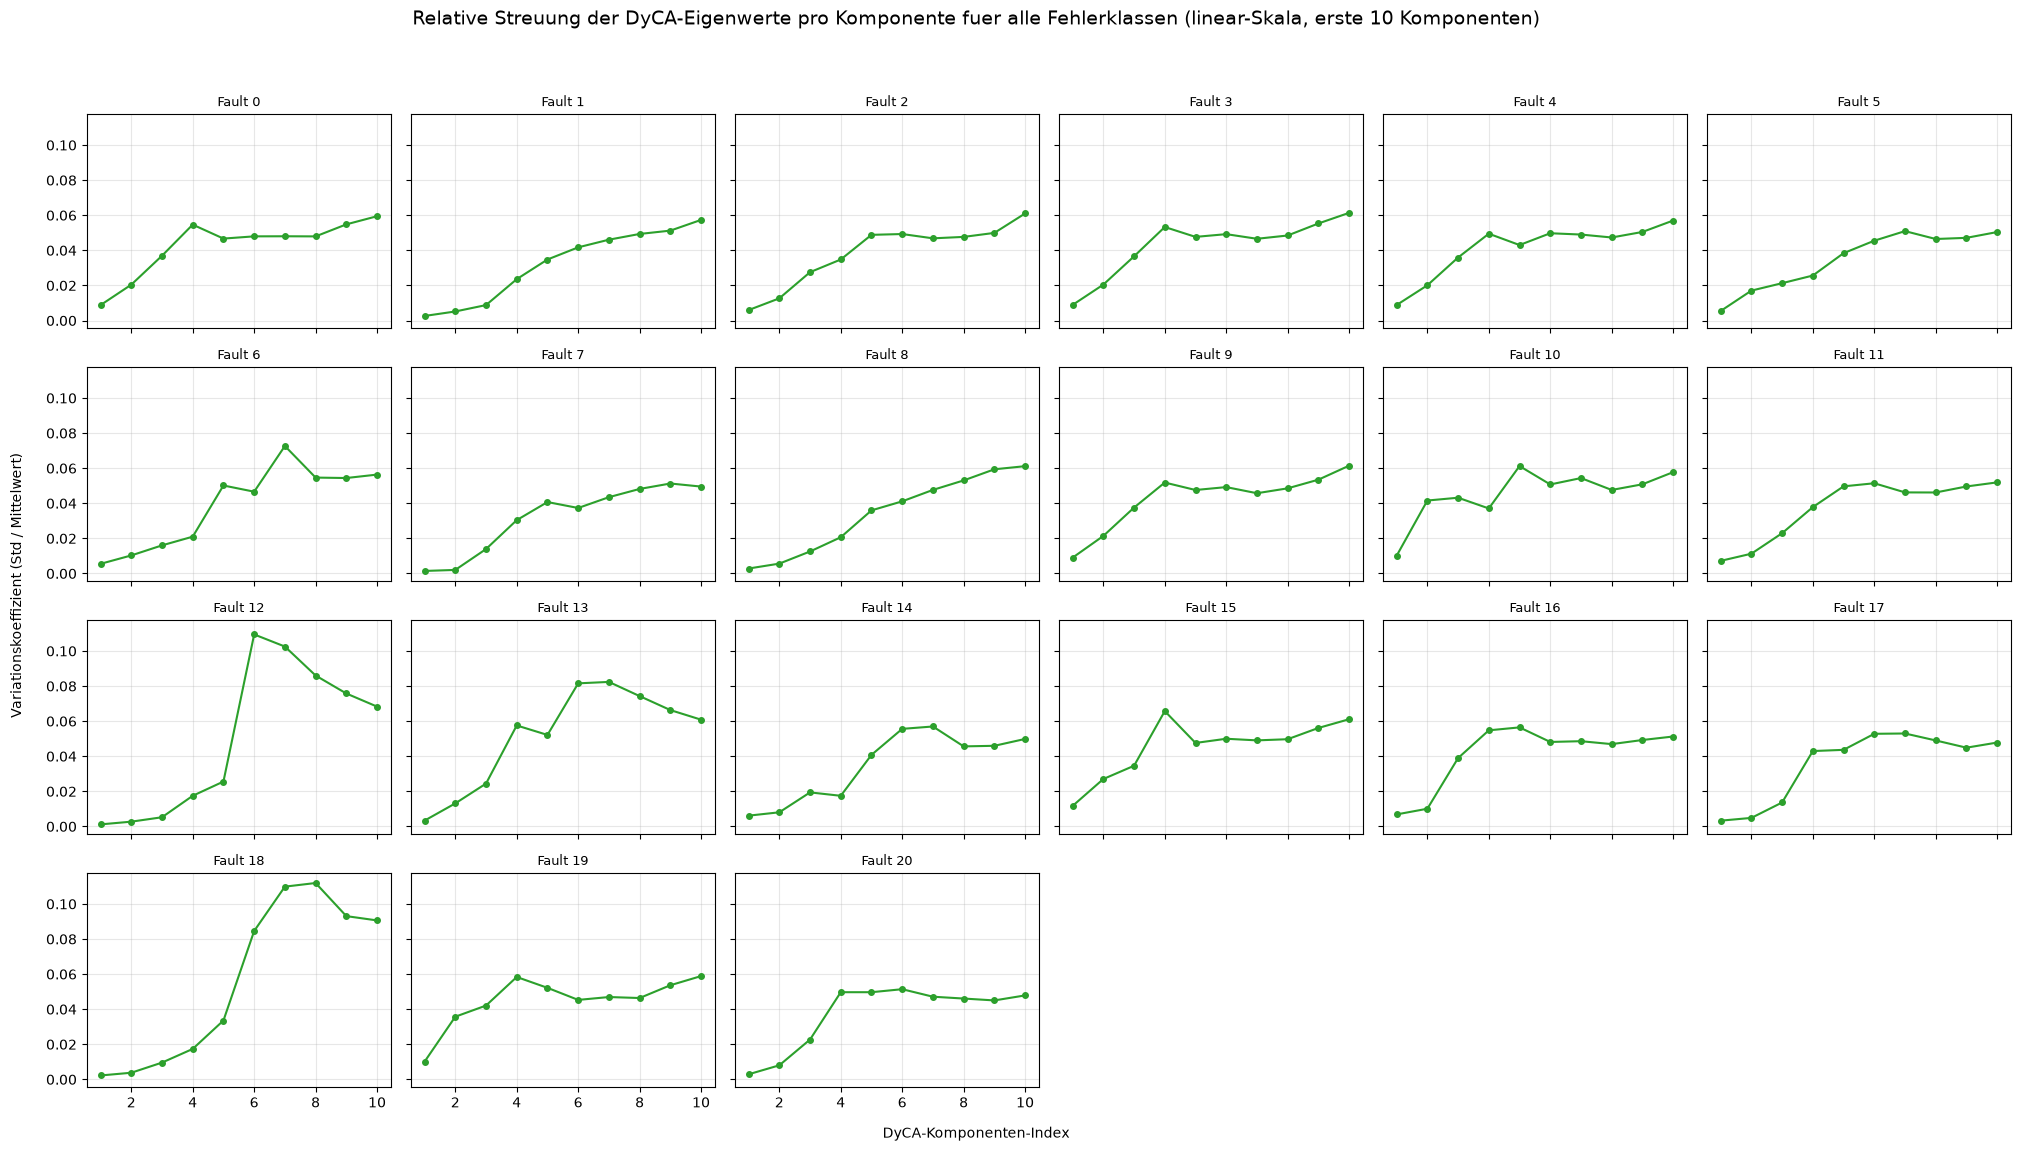

In [13]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der RELATIVEN STREUUNG (Variationskoeffizient) der Eigenwerte
# ueber die ersten k Komponenten.
#
#     CV_i = dyca_i_std / dyca_i_mean
#
# K_MAX_DYCA und transform_eigenvalues kommen aus der Mittelwerts-Zelle.
# ============================================================

# Eigener Skalen-Modus fuer diesen Plot - unabhaengig vom globalen
# plot_mode der beiden vorigen Plots. Bewusst LINEAR, weil CVs
# dimensionslose Verhaeltnisse sind und im Bereich 0..1 (oft 0..0.3)
# liegen; lineare y-Achse ist intuitiver lesbar als log10.
plot_mode_cv = "linear"


def plot_dyca_cv_per_fault(agg_df, eig_prefix="dyca_", k_max=K_MAX_DYCA):
    eig_cols_mean = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_mean")
    ]
    eig_cols_std  = [
        c for c in agg_df.columns
        if c.startswith(eig_prefix) and c.endswith("_std")
    ]
    eig_cols_mean = sorted(eig_cols_mean, key=lambda c: int(c.split("_")[1]))
    eig_cols_std  = sorted(eig_cols_std,  key=lambda c: int(c.split("_")[1]))

    # Auf die ersten k_max Komponenten begrenzen.
    eig_cols_mean = eig_cols_mean[:k_max]
    eig_cols_std  = eig_cols_std[:k_max]
    K = len(eig_cols_mean)

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)

    ncols = 6
    nrows = int(np.ceil(n_faults / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    x = np.arange(1, K + 1)

    for i, fault in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == fault].iloc[0]

        mean_vals = np.array([row[c] for c in eig_cols_mean], dtype=float)
        std_vals  = np.array([row[c] for c in eig_cols_std],  dtype=float)

        # CV elementweise; bei mean nahe 0 -> NaN, um Division durch
        # numerisches Null zu vermeiden.
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = np.where(mean_vals > 0, std_vals / mean_vals, np.nan)

        # Lokaler plot_mode_cv - unabhaengig vom globalen plot_mode.
        y_vals = transform_eigenvalues(cv, mode=plot_mode_cv)

        ax.plot(x, y_vals, "o-", color="tab:green", markersize=4)
        ax.set_title(f"Fault {fault}", fontsize=9)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # y-Achsen-Beschriftung passt sich an den lokalen Modus an.
    if plot_mode_cv == "log":
        y_label = "log10(CV) = log10(Std / Mittelwert)"
    elif plot_mode_cv == "relative":
        y_label = "CV_i / CV_1"
    else:
        y_label = "Variationskoeffizient (Std / Mittelwert)"

    fig.suptitle(
        f"Relative Streuung der DyCA-Eigenwerte pro Komponente fuer alle Fehlerklassen "
        f"({plot_mode_cv}-Skala, erste {K} Komponenten)",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "DyCA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_dyca_cv_per_fault(agg)

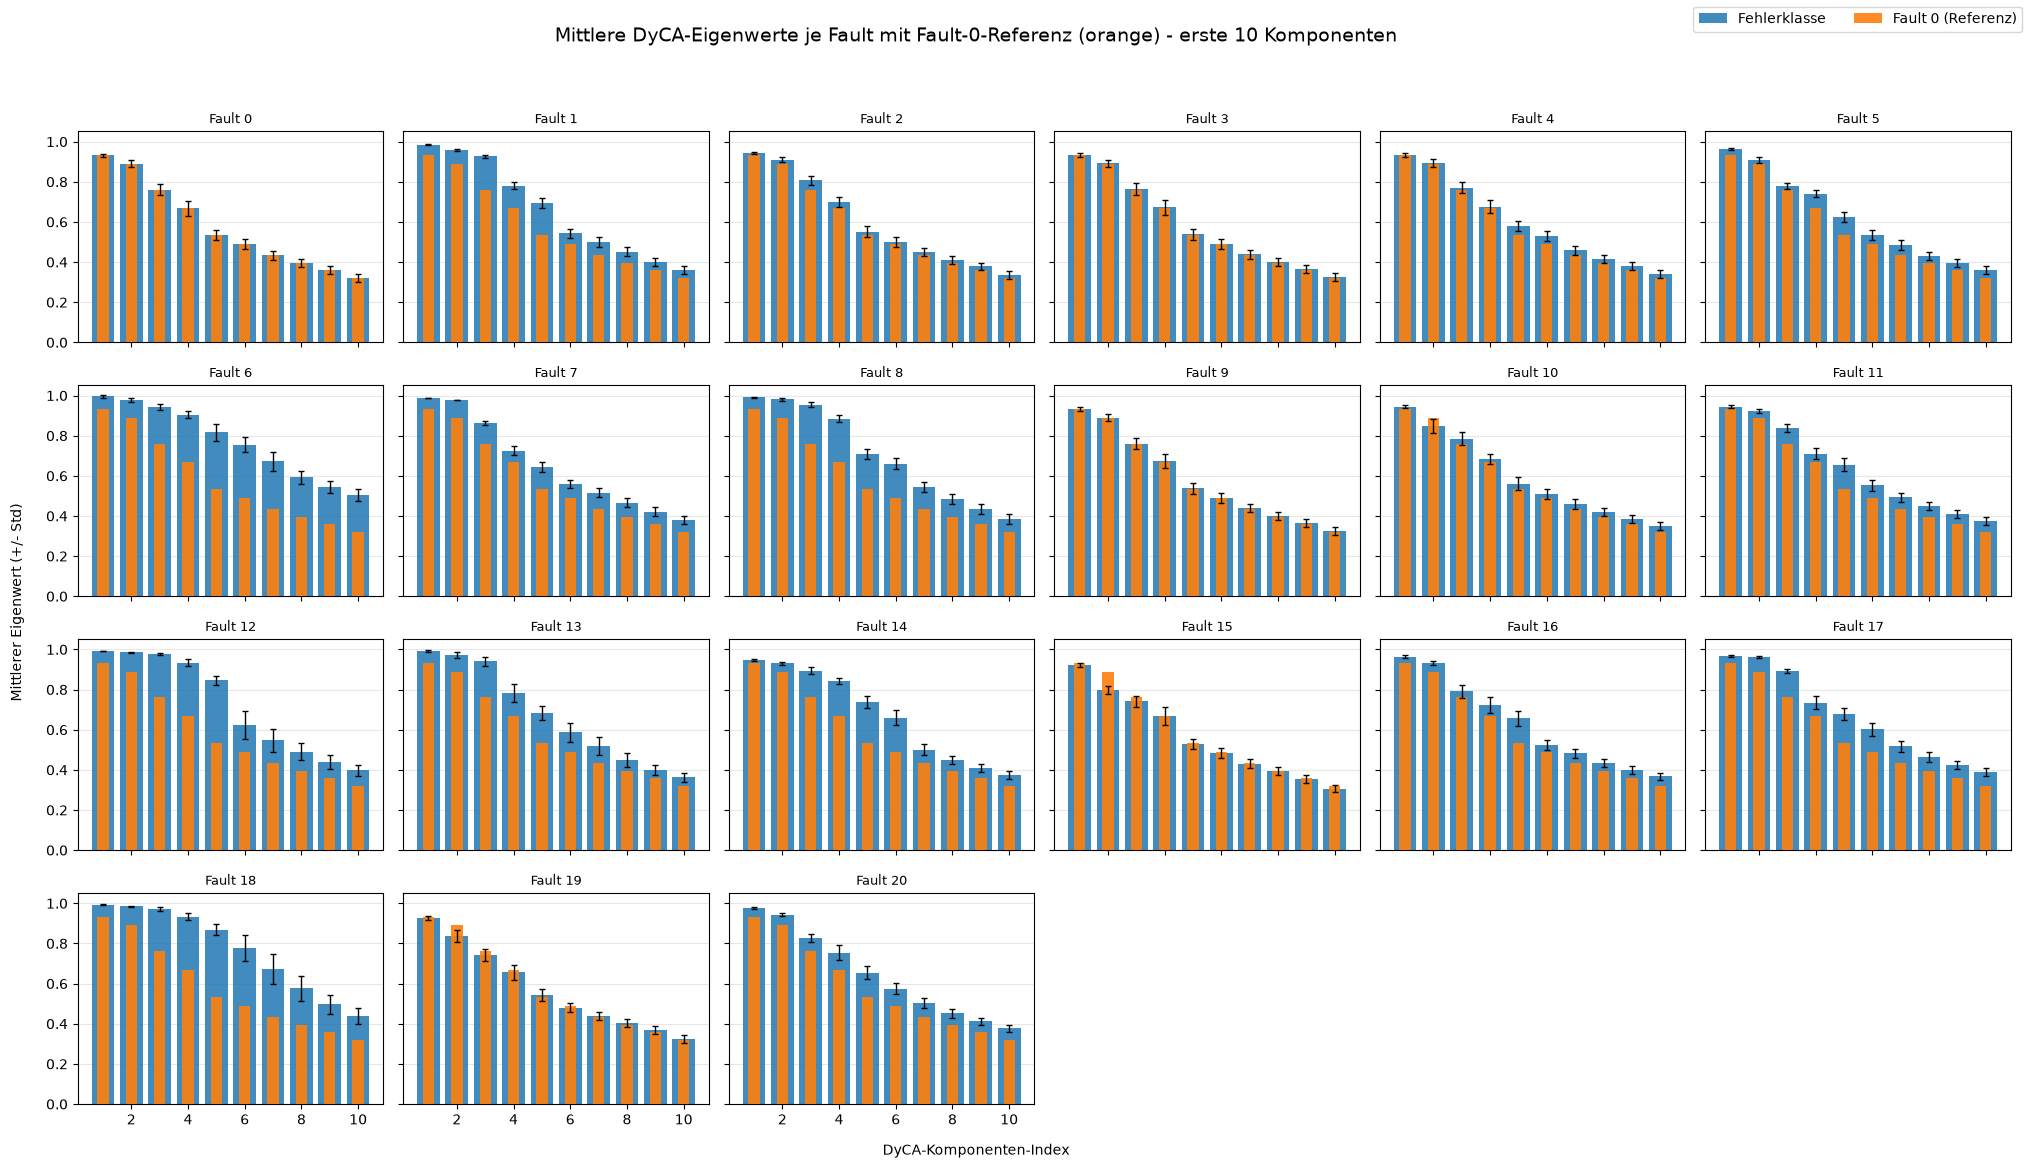

In [14]:
# ============================================================
# Bar-Plot: erste k DyCA-Eigenwerte je Fault MIT Fault-0-Overlay
# ============================================================
# Pro Fehlerklasse ein Subplot:
#   - breite blaue Balken  = mittlerer DyCA-Eigenwert der Klasse,
#   - schmale orange Balken= Eigenwert-Mittelwert von Fault 0 (Normal-
#                            betrieb), zentriert oben drauf als Referenz,
#   - schwarze Fehlerbalken= +/- Std ueber die erfolgreichen Runs, werden
#                            ZULETZT gezeichnet (hoechster zorder), damit
#                            sie nicht vom orange Balken verdeckt werden.
# So ist je Fault direkt ablesbar, welche der ersten k generalisierten
# Eigenwerte vom fehlerfreien Betrieb abweichen.
#
# Lesehilfe: Faults mit fast deckungsgleicher orange Referenz sind anhand
# des Spektrums kaum vom Normalbetrieb zu unterscheiden. Der Subplot
# "Fault 0" zeigt die Referenz auf sich selbst (Sanity-Check).

def plot_dyca_bars_with_ref(agg_df, eig_prefix="dyca_", k_bar=10):
    mean_cols_bar = [f"{eig_prefix}{i}_mean" for i in range(1, k_bar + 1)]
    std_cols_bar  = [f"{eig_prefix}{i}_std"  for i in range(1, k_bar + 1)]

    faults   = np.sort(agg_df["faultNumber"].unique())
    n_faults = len(faults)
    ncols    = 6
    nrows    = int(np.ceil(n_faults / ncols))

    # Referenz-Spektrum: Mittelwerte von Fault 0 (Normalbetrieb).
    ref_means = agg_df[agg_df["faultNumber"] == 0].iloc[0][mean_cols_bar].values.astype(float)

    x = np.arange(1, k_bar + 1)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.5 * ncols, 3.0 * nrows),
        sharex=True, sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for i, f in enumerate(faults):
        ax  = axes[i]
        row = agg_df[agg_df["faultNumber"] == f].iloc[0]
        means = row[mean_cols_bar].values.astype(float)
        stds  = row[std_cols_bar].values.astype(float)

        # Klasse f: breite Balken (blau), OHNE yerr (Fehlerbalken kommen unten).
        ax.bar(x, means, width=0.8,
               color="C0", alpha=0.85,
               label="Fehlerklasse", zorder=2)
        # Fault 0 (Referenz): schmale orange Balken oben drauf.
        ax.bar(x, ref_means, width=0.4,
               color="tab:orange", alpha=0.9,
               label="Fault 0 (Referenz)", zorder=3)
        # Std-Fehlerbalken ZULETZT -> liegen sichtbar ueber dem orange Balken.
        ax.errorbar(x, means, yerr=stds, fmt="none",
                    ecolor="black", capsize=2, elinewidth=1, zorder=4)

        ax.set_title(f"Fault {f}", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)

    # Unbenutzte Achsen ausblenden.
    for j in range(n_faults, len(axes)):
        axes[j].set_visible(False)

    # Gemeinsame Legende (generische Labels aus dem ersten Subplot).
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=10)

    fig.suptitle(
        f"Mittlere DyCA-Eigenwerte je Fault mit Fault-0-Referenz (orange) "
        f"- erste {k_bar} Komponenten",
        fontsize=14,
    )
    fig.text(0.5,  0.04, "DyCA-Komponenten-Index", ha="center")
    fig.text(0.04, 0.5,  "Mittlerer Eigenwert (+/- Std)", va="center", rotation="vertical")

    plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
    plt.show()


plot_dyca_bars_with_ref(agg)

In [15]:
# ============================================================
# Export: DyCA-Eigenwerte (Training) als CSV
# ============================================================
# Stellt die TRAININGS-Eigenwerte fuer das LazyClassifier-Notebook bereit.
# Die TEST-Eigenwerte werden bewusst NICHT hier berechnet, sondern direkt
# im LazyClassifier_PCA_DyCA.ipynb -> dieses Notebook bleibt training-only.
dyca_eigenvalues_per_run.to_csv("dyca_eigenvalues_train.csv", index=False)
print("DyCA-Train gespeichert:", dyca_eigenvalues_per_run.shape,
      "-> dyca_eigenvalues_train.csv")

DyCA-Train gespeichert: (10443, 54) -> dyca_eigenvalues_train.csv
